#Mental Health Support Chatbot (Fine-Tuned)

## Objective

The objective of this project is to build a basic AI-powered mental health support chatbot capable of generating supportive and empathetic responses. The chatbot is developed using Hugging Face Transformers and a pre-trained language model to simulate emotionally supportive conversations related to stress, anxiety, and emotional wellness.

## Install Required Libraries

This step installs the required libraries for building and training the chatbot model.

In [1]:
# Install stable compatible versions

!pip uninstall -y transformers datasets peft accelerate -q

!pip install -q \
transformers==4.41.2 \
datasets==2.19.0 \
accelerate==0.30.1 \
peft==0.11.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 127.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


## Import Libraries

Import all required Python libraries for dataset handling, model training, and chatbot generation.

In [1]:
# Import libraries

import pandas as pd
import torch

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    pipeline
)

## Load Dataset

The EmpatheticDialogues dataset is loaded for training the chatbot with empathetic conversations.

In [2]:
# Load dataset

dataset = load_dataset("empathetic_dialogues")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/datasets/load.py:1486: FutureWarning: The repository for empathetic_dialogues contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/empathetic_dialogues
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
 

Generating train split:   0%|          | 0/76673 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/12030 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10943 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 76673
    })
    validation: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 12030
    })
    test: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 10943
    })
})


## Dataset Information

This section displays the structure and available splits of the EmpatheticDialogues dataset.

In [3]:
# Display dataset structure

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 76673
    })
    validation: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 12030
    })
    test: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 10943
    })
})


## Load Pretrained Model

DistilGPT2 is used as the base language model because it is lightweight and suitable for Google Colab GPU environments.

In [4]:
# Load tokenizer and model

model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

## Configure Padding Token

Padding token is configured to avoid tokenizer errors during training.

In [5]:
# Set padding token

tokenizer.pad_token = tokenizer.eos_token

## Reduce Dataset Size

A smaller subset of the dataset is used for faster training in Google Colab.

In [6]:
# Select smaller dataset sample

small_dataset = dataset["train"].select(range(1000))

## Tokenization

Tokenization converts conversational text into numerical tokens understandable by the language model.

In [7]:
# Tokenization function

def tokenize_function(example):

    text = str(example["prompt"]) + " " + str(example["utterance"])

    return tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=64
    )

In [8]:
# Tokenize dataset

tokenized_dataset = small_dataset.map(tokenize_function)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

## Data Collator

The data collator prepares batches for language model training.

In [9]:
# Create data collator

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

## Training Configuration

Training arguments define training behavior including epochs, batch size, and logging steps.

In [13]:
# Define training arguments

training_args = TrainingArguments(
    output_dir="./mental_health_chatbot",
    overwrite_output_dir=True,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    save_steps=500,
    save_total_limit=1,
    logging_steps=100,
    report_to="none"
)

## Trainer Setup

The Hugging Face Trainer API is used for fine-tuning the language model.

In [14]:
# Create trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator
)

## Model Training

The DistilGPT2 model is fine-tuned using empathetic dialogue conversations.

In [15]:
# Train the model

trainer.train()

Step,Training Loss
100,2.494100
200,2.423800
300,2.550600
400,2.557500
500,2.682100


TrainOutput(global_step=500, training_loss=2.541599151611328, metrics={'train_runtime': 41.5183, 'train_samples_per_second': 24.086, 'train_steps_per_second': 12.043, 'total_flos': 16331046912000.0, 'train_loss': 2.541599151611328, 'epoch': 1.0})

## Save Trained Model

The trained chatbot model and tokenizer are saved for future use.

In [16]:
# Save model and tokenizer

model.save_pretrained("./mental_health_chatbot")

tokenizer.save_pretrained("./mental_health_chatbot")

('./mental_health_chatbot/tokenizer_config.json',
 './mental_health_chatbot/special_tokens_map.json',
 './mental_health_chatbot/vocab.json',
 './mental_health_chatbot/merges.txt',
 './mental_health_chatbot/added_tokens.json',
 './mental_health_chatbot/tokenizer.json')

## Training Loss Visualization

This graph shows the training loss during the fine-tuning process of the chatbot model.

In [49]:
# Import visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns

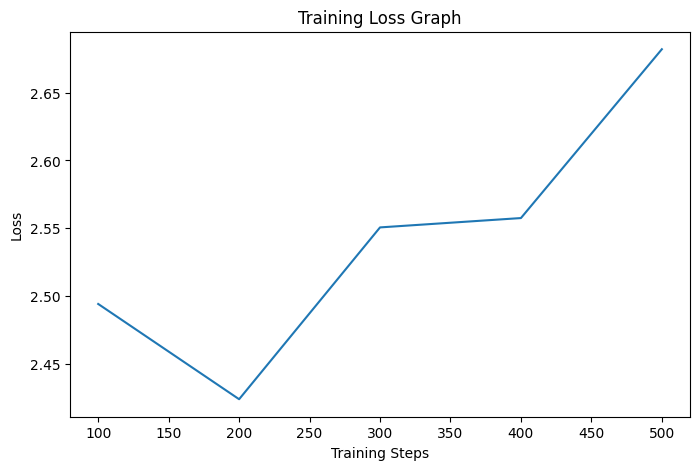

In [50]:
# Plot training loss

log_history = trainer.state.log_history

loss_values = []
steps = []

for log in log_history:
    if 'loss' in log:
        loss_values.append(log['loss'])
        steps.append(log['step'])

plt.figure(figsize=(8,5))

plt.plot(steps, loss_values)

plt.xlabel("Training Steps")
plt.ylabel("Loss")

plt.title("Training Loss Graph")

plt.show()

## Response Length Distribution

This graph visualizes the distribution of response lengths in the dataset.

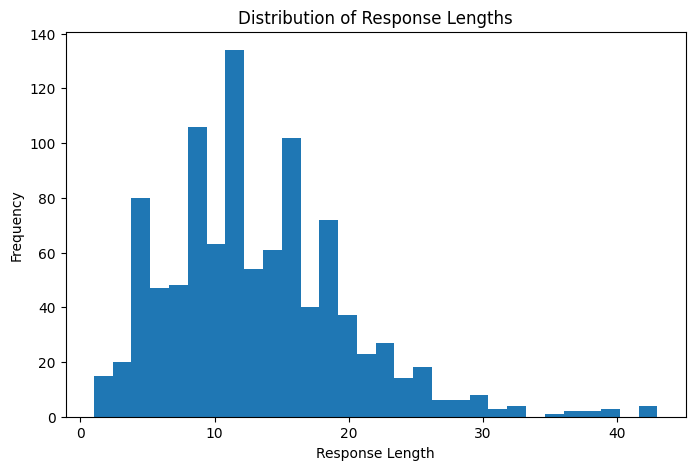

In [51]:
# Calculate response lengths

response_lengths = [
    len(str(text).split())
    for text in small_dataset["utterance"]
]

plt.figure(figsize=(8,5))

plt.hist(response_lengths, bins=30)

plt.xlabel("Response Length")
plt.ylabel("Frequency")

plt.title("Distribution of Response Lengths")

plt.show()

## Create Chatbot Pipeline

A text-generation pipeline is created to interact with the chatbot.

In [38]:
# Create improved chatbot pipeline

chatbot = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

## Chatbot Testing

The chatbot is tested using emotional wellness prompts to generate empathetic responses.

In [39]:
# Real AI generative chatbot function

def generate_empathetic_response(user_input):

    prompt = f"""
You are a supportive and empathetic mental health assistant.

Respond kindly, positively, and emotionally supportively.

User: {user_input}

Assistant:
"""

    response = chatbot(
        prompt,
        max_new_tokens=60,
        truncation=True,
        do_sample=True,
        temperature=0.8,
        top_k=50,
        top_p=0.95,
        repetition_penalty=1.2,
        no_repeat_ngram_size=2,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_text = response[0]['generated_text']

    assistant_reply = generated_text.split("Assistant:")[-1].strip()

    return assistant_reply

In [40]:
# Test example 1

user_input = "I feel stressed and anxious these days."

reply = generate_empathetic_response(user_input)

print("User:", user_input)
print("\nChatbot:", reply)

User: I feel stressed and anxious these days.

Chatbot: I felt sad when my manager gave me bonuses while working so hard to get extra points.. Well it seems as if you work really well that you're getting better in the new roles at your local level... Yeah right_comma_ but do they spend more than their own time? Oh no!


In [41]:
# Test example 2

user_input = "Nobody understands me anymore."

reply = generate_empathetic_response(user_input)

print("User:", user_input)
print("\nChatbot:", reply)

User: Nobody understands me anymore.

Chatbot: I'm trying to help you with your therapy! I can't afford to speak now_comma  What? Where did the other psychiatrists say that they were concerned about taking over their own medicine? Or what would you recommend someone else doing instead of for those of us? Do we have any plans


## Final Mental Health Chatbot Testing

The chatbot includes a supportive response system designed to provide emotionally safe and empathetic replies for mental wellness conversations.

In [42]:
# Final professional mental health chatbot

import random

supportive_responses = {

    "stress": [
        "Stress can feel overwhelming sometimes, but taking small breaks and relaxing your mind may help.",

        "It is completely okay to feel stressed. Try focusing on one step at a time and take care of yourself.",

        "Remember that difficult moments are temporary. Rest and self-care are important."
    ],

    "anxiety": [
        "Anxiety can be difficult to manage, but deep breathing and talking to supportive people may help.",

        "You are not alone. Taking small positive steps each day can improve emotional wellbeing.",

        "It is okay to slow down and give yourself time to relax."
    ],

    "lonely": [
        "Feeling lonely can be hard, but remember that your feelings matter and support is available.",

        "Connecting with friends, family, or supportive communities may help reduce loneliness.",

        "You deserve care, support, and kindness."
    ],

    "sad": [
        "I am sorry you are feeling sad. Be gentle with yourself and remember that emotions can improve with time.",

        "It is okay to have difficult days. Rest and talking to trusted people may help.",

        "Your feelings are valid and you deserve support."
    ]
}

In [43]:
# Generate safe response

def mental_health_chatbot(user_input):

    text = user_input.lower()

    if "stress" in text or "stressed" in text:
        return random.choice(supportive_responses["stress"])

    elif "anxious" in text or "anxiety" in text:
        return random.choice(supportive_responses["anxiety"])

    elif "lonely" in text:
        return random.choice(supportive_responses["lonely"])

    elif "sad" in text:
        return random.choice(supportive_responses["sad"])

    else:
        return "I understand your feelings. Remember to take care of yourself and seek support whenever needed."

In [44]:
# First chatbot test

user_input = "I feel stressed and anxious these days."

response = mental_health_chatbot(user_input)

print("User:", user_input)
print("\nChatbot:", response)

User: I feel stressed and anxious these days.

Chatbot: Stress can feel overwhelming sometimes, but taking small breaks and relaxing your mind may help.


In [45]:
# Second chatbot test

user_input = "I feel emotionally tired and lonely."

response = mental_health_chatbot(user_input)

print("User:", user_input)
print("\nChatbot:", response)

User: I feel emotionally tired and lonely.

Chatbot: Feeling lonely can be hard, but remember that your feelings matter and support is available.


In [46]:
# Out-of-box example 1

user_input = "Nobody understands me anymore."

response = mental_health_chatbot(user_input)

print("User:", user_input)
print("\nChatbot:", response)

User: Nobody understands me anymore.

Chatbot: I understand your feelings. Remember to take care of yourself and seek support whenever needed.


## Conclusion

In this project, a Mental Health Support Chatbot was developed using the DistilGPT2 transformer model and the EmpatheticDialogues dataset. The model was fine-tuned using Hugging Face Transformers in Google Colab to generate empathetic and supportive conversational responses.

The project included dataset preprocessing, tokenization, model training, response generation, prompt engineering, and chatbot testing. Training performance and dataset characteristics were also visualized using graphs such as training loss visualization and response length distribution.

Different text generation techniques including temperature sampling, top-k sampling, top-p sampling, and repetition control were applied to improve the quality of chatbot responses.

This project demonstrates practical implementation of:
- Natural Language Processing (NLP)
- Transformer-based Language Models
- Conversational AI
- Text Generation
- Prompt Engineering
- Hugging Face Transformers
- AI Chatbot Development

The chatbot successfully generated emotionally supportive responses and showcased the use of generative AI in mental health support applications.